Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 11.77it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

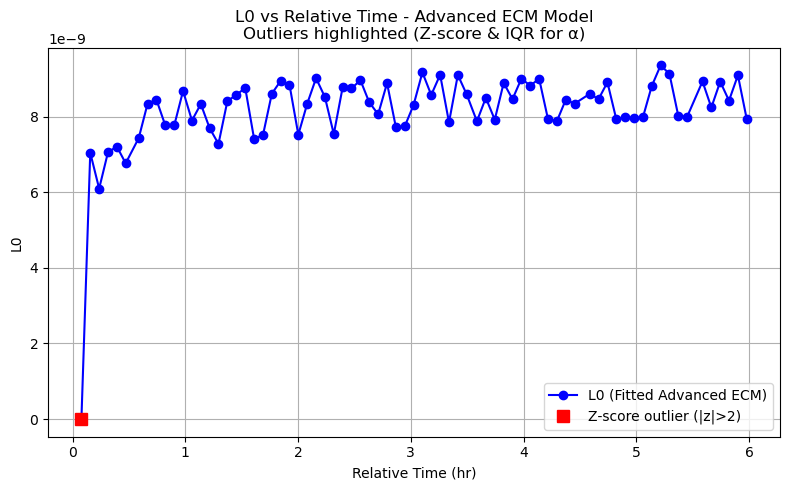

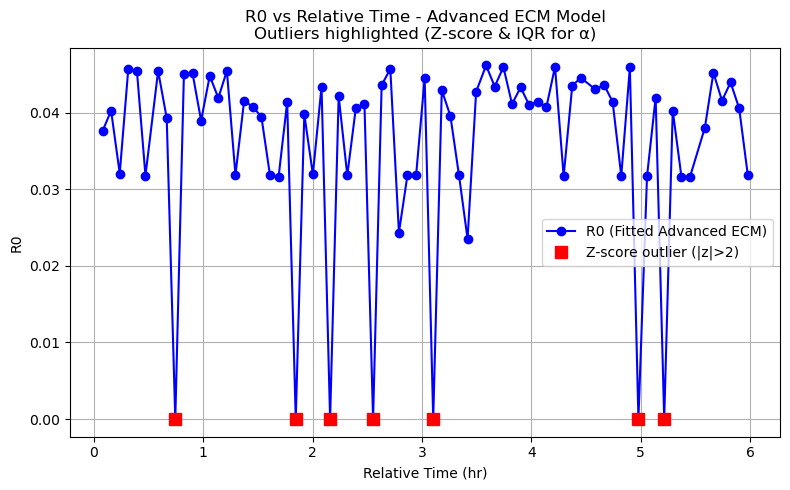

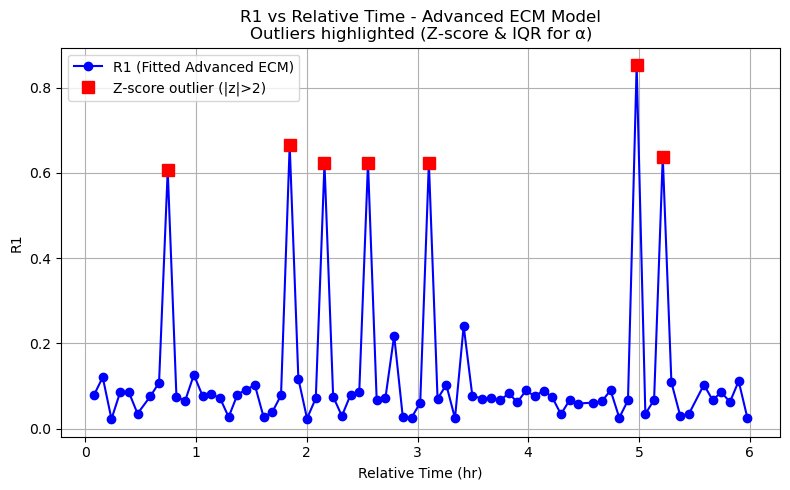

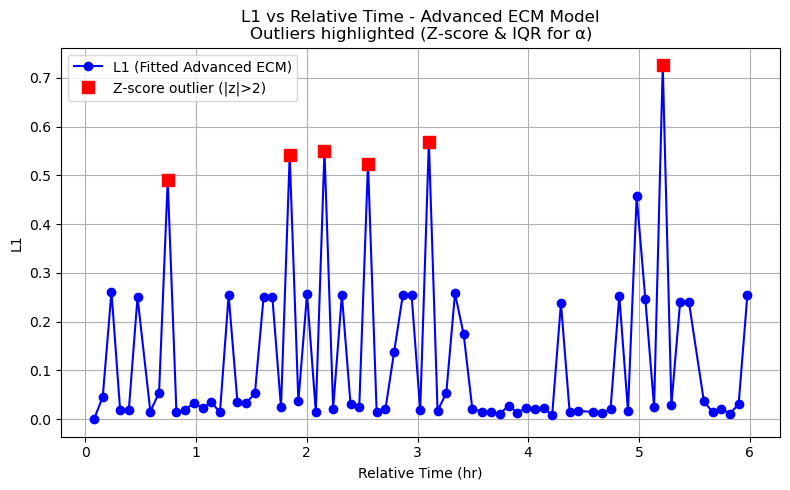

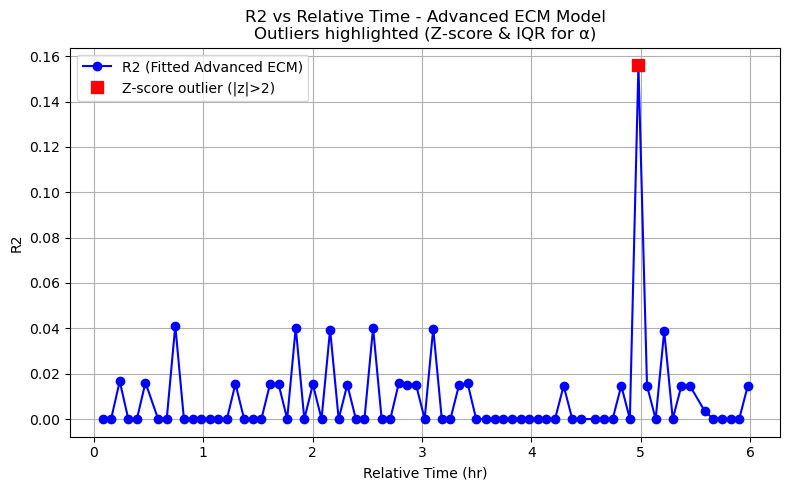

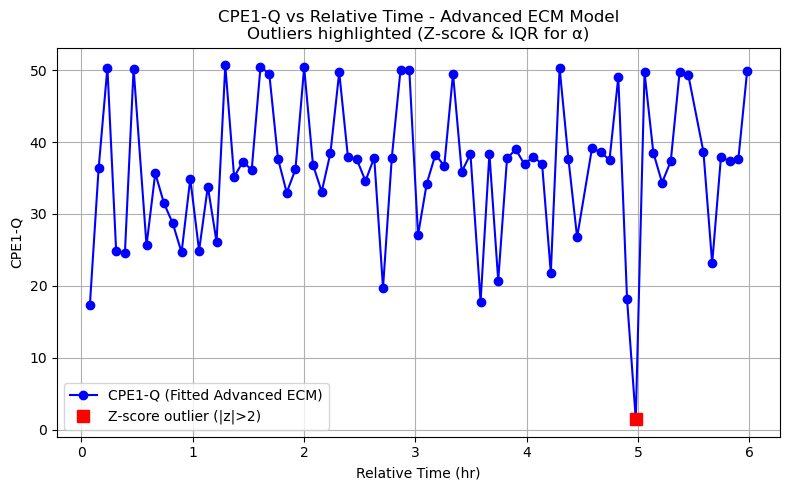

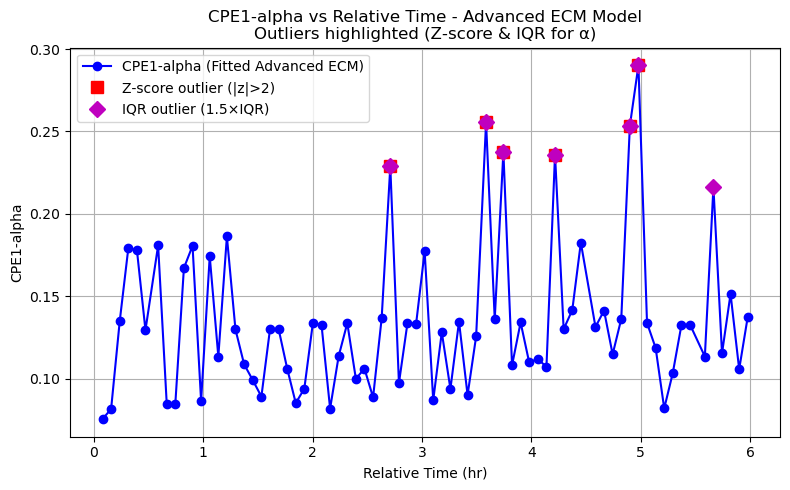

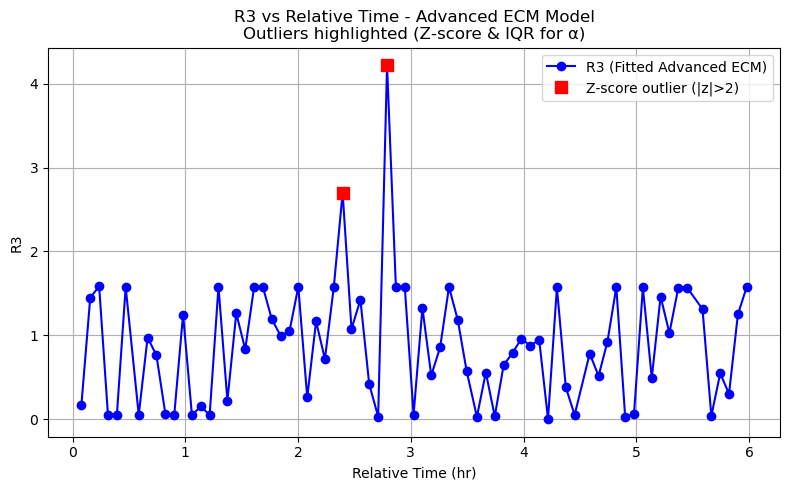

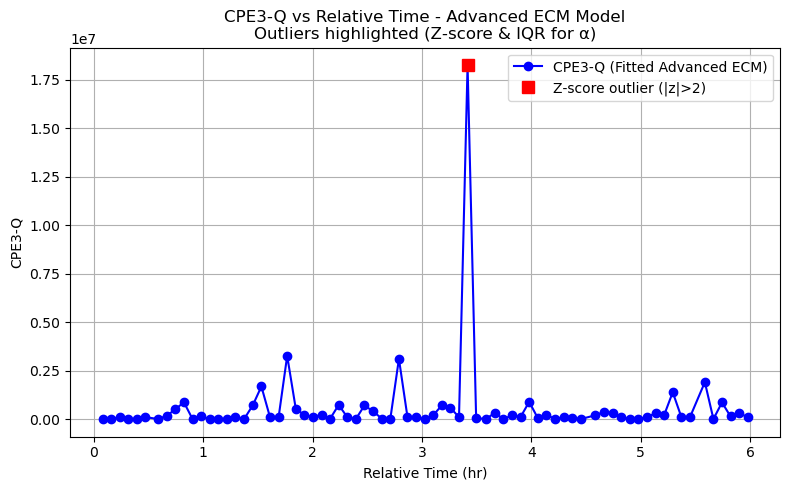

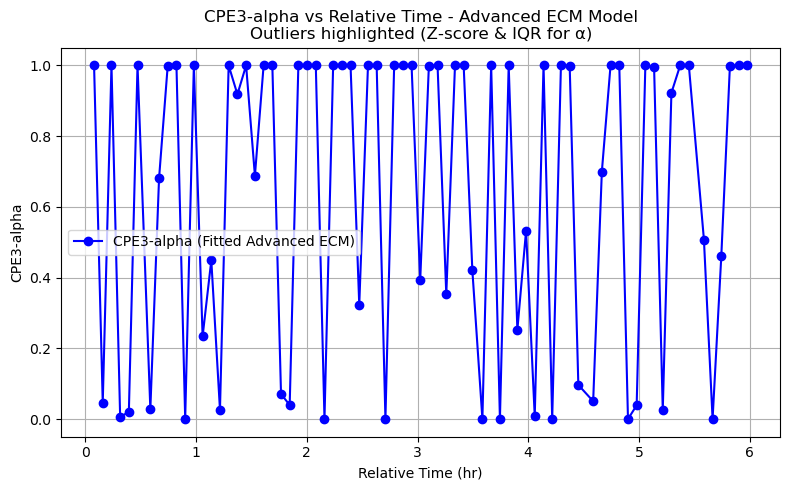

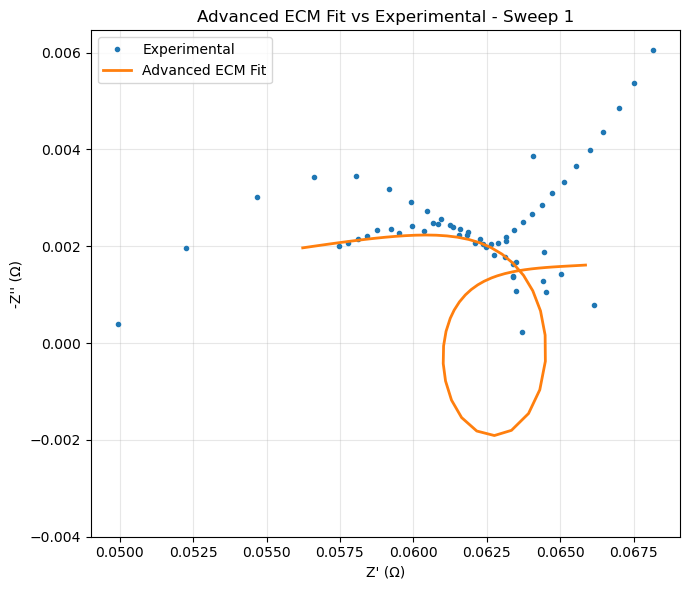

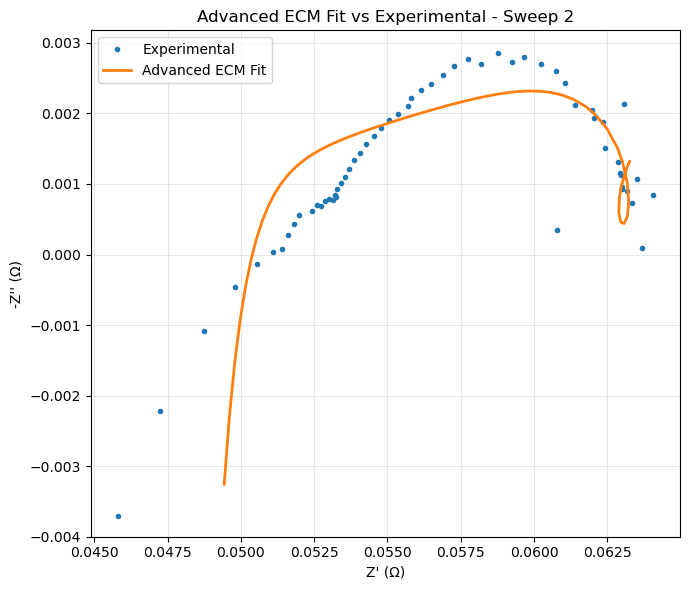

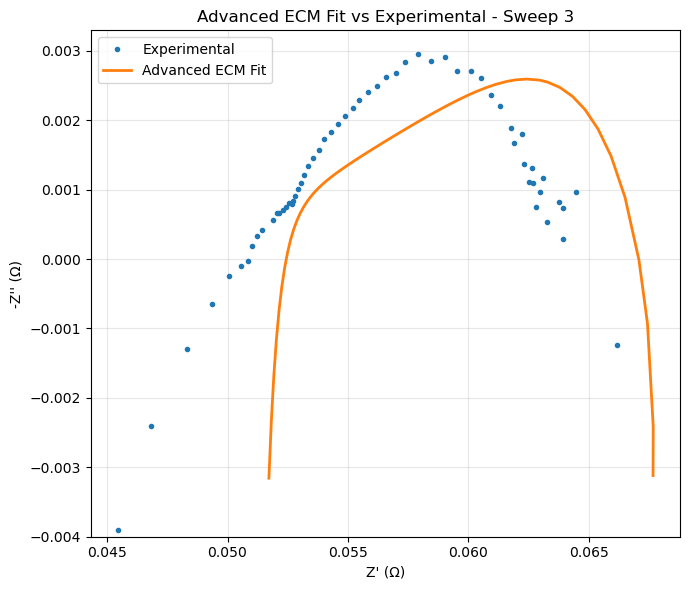

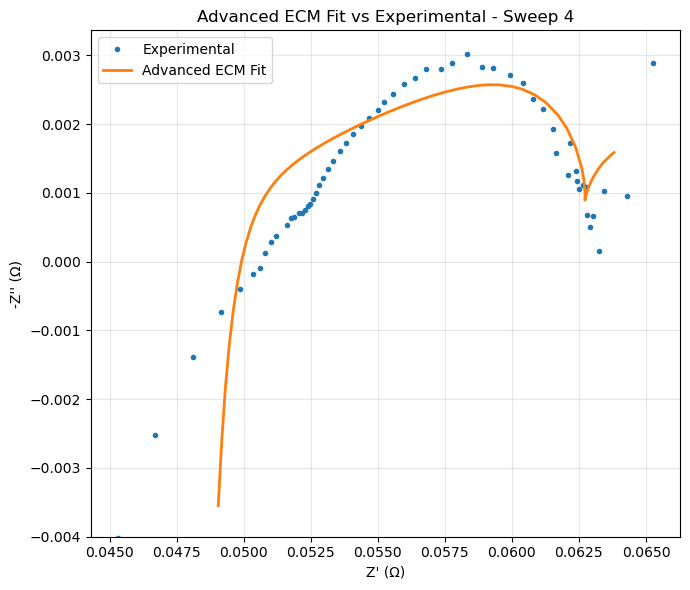

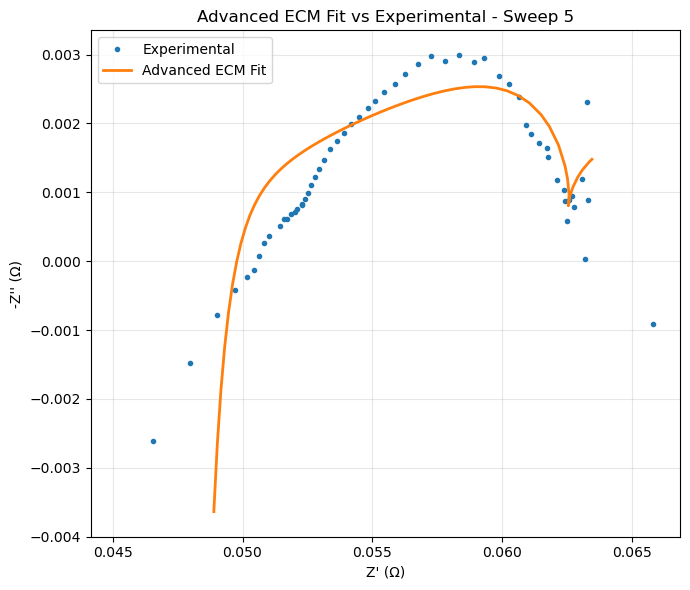

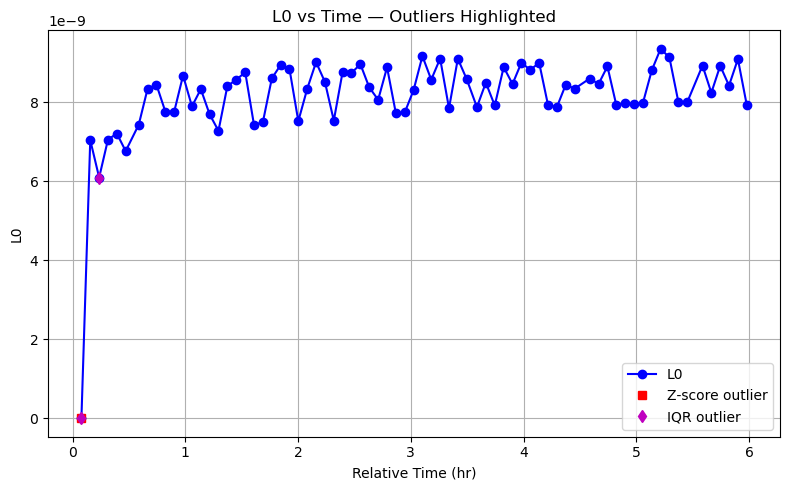

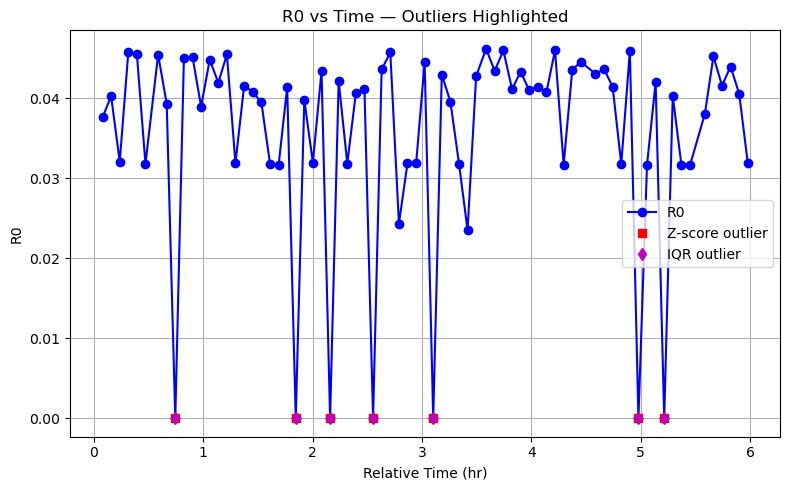

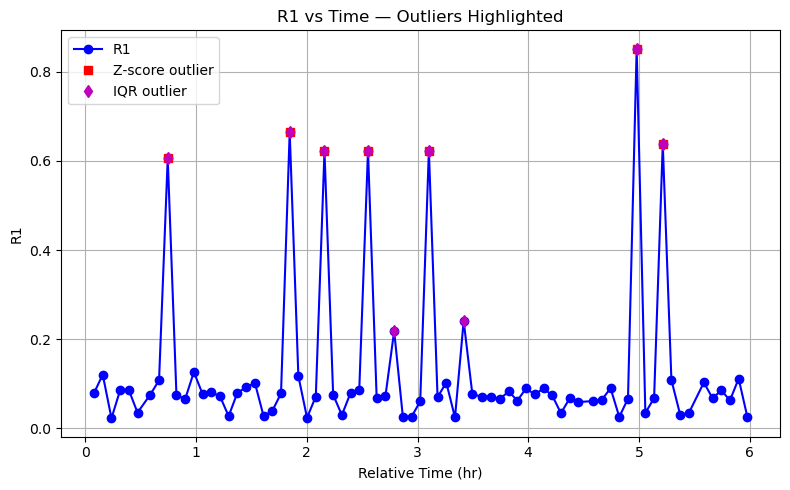

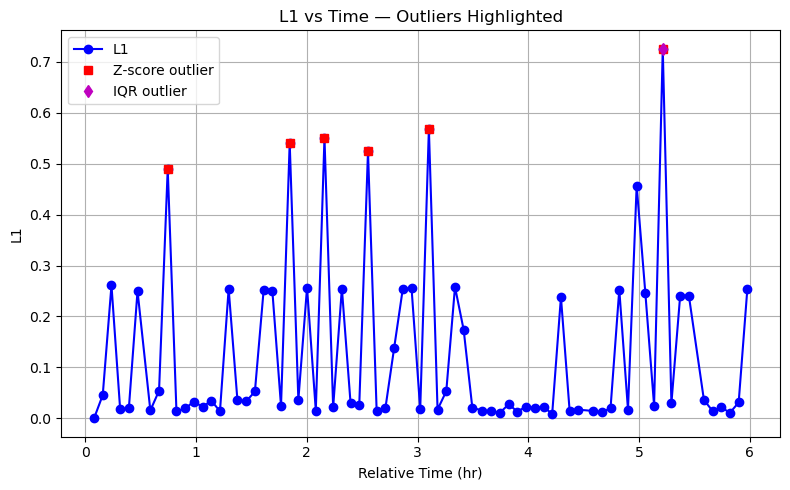

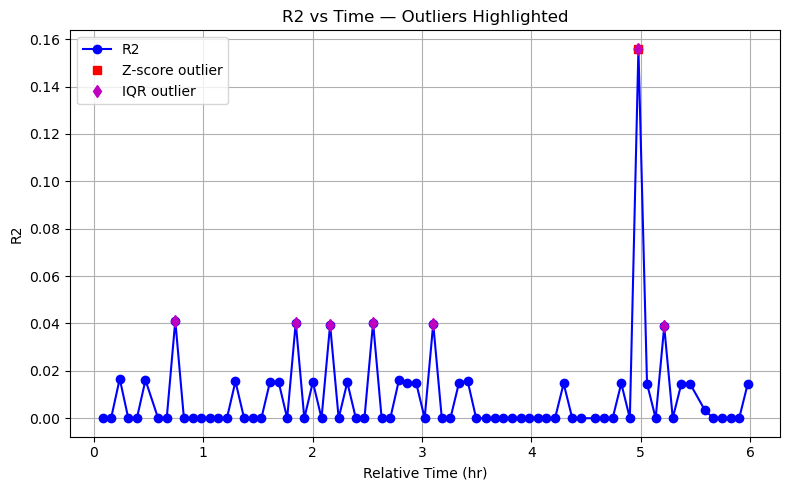

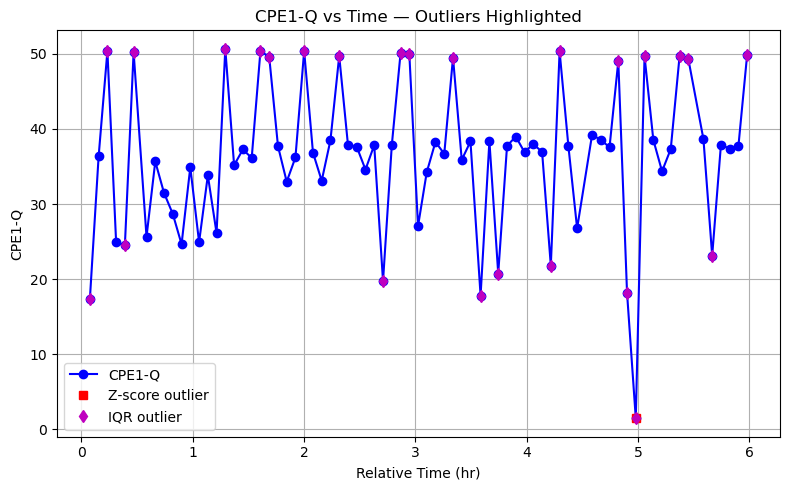

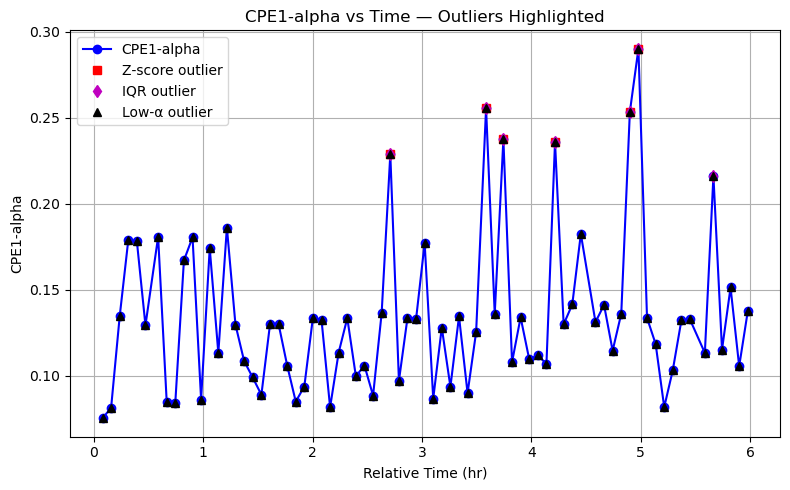

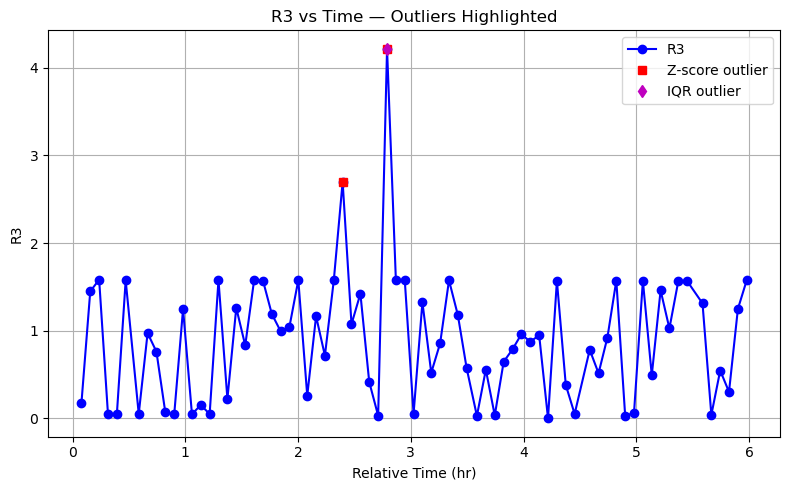

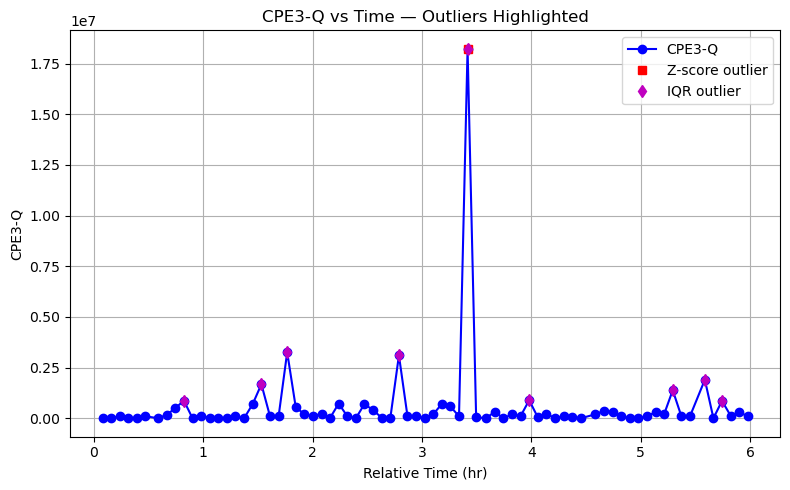

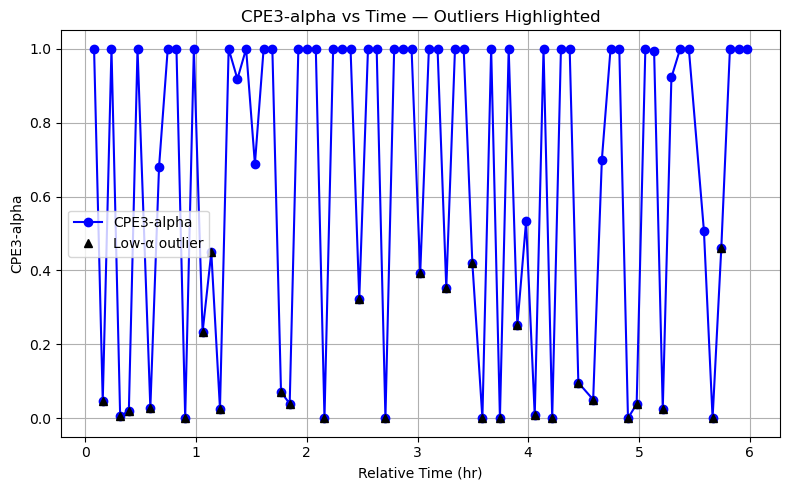

=== RMSE Comparison ===
Majority (n=33): mean RMSE = 9.538e-04, median RMSE = 9.470e-04
Outliers (n=41): mean RMSE = 1.408e-03, median RMSE = 1.010e-03

Plotting best‐majority (sweep 69) and worst‐outlier (sweep 1):


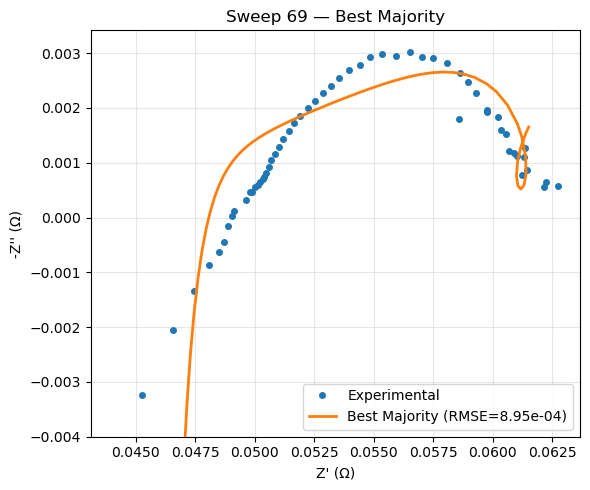

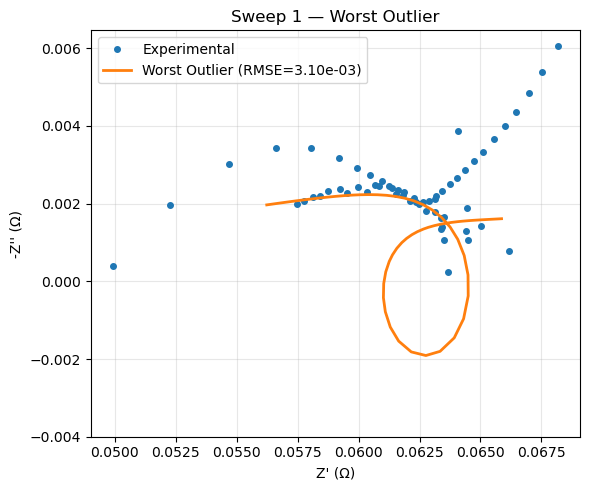

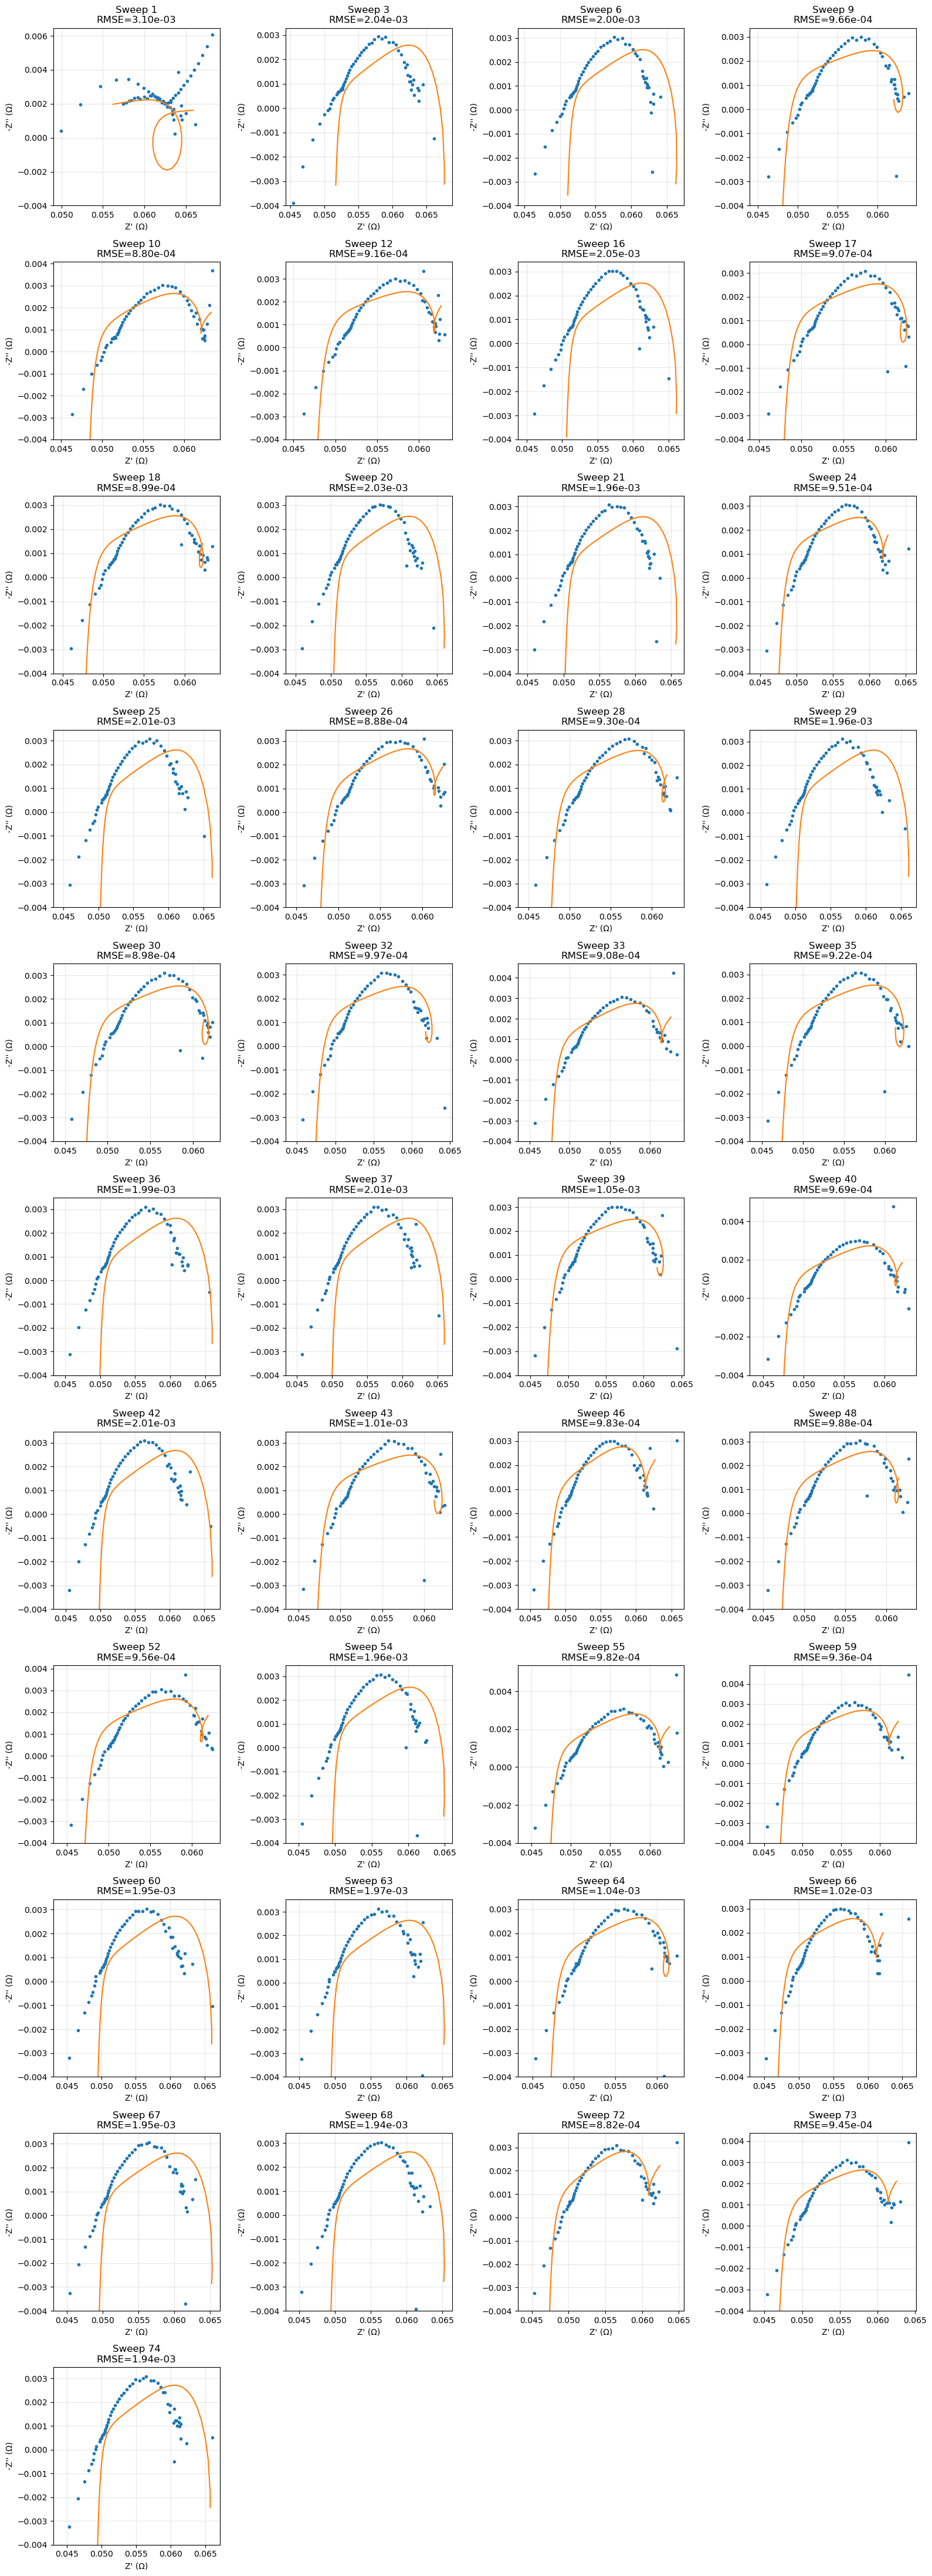

Saved outliers for review to 'outliers_for_review.xlsx':
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
2  Advanced_2RCPE  [6.766448420875111e-09, 0.03179311341917051, 0...   
3  Advanced_2RCPE  [8.44881823733268e-09, 4.112435112038162e-07, ...   
4  Advanced_2RCPE  [7.767734366795931e-09, 0.04505812649450435, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.001999 -1554.858345   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000966 -1729.250821   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000880 -1751.720137   

           bic  sweep_id           

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path

from impedance.models.circuits import CustomCircuit
from impedance import preprocessing

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

###############################################################################
# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
###############################################################################
file_path = "6300.xls"  # Path to your Excel file
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer the "Probe Frequency Domain" sheet if available
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

###############################################################################
# 2. DATA CLEANUP & TIME DERIVATION
###############################################################################
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

###############################################################################
# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
###############################################################################
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

###############################################################################
# 4. DEFINE ECM MODELS WITH INITIAL GUESSES
###############################################################################
# Advanced model candidate information
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}

# (You can define other candidate models if needed; here we focus on advanced_model_info)
model_candidates = [advanced_model_info]

###############################################################################
# 5. ECM FITTING FUNCTION FOR ADVANCED MODEL
###############################################################################
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# For simplicity, fit the advanced model for each sweep
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

###############################################################################
# 6. PLOT ADVANCED MODEL PARAMETERS VS. EXPERIMENTAL VALUES WITH OUTLIER DETECTION
###############################################################################
# Expand advanced model parameters into separate columns
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Merge relative time from df_eis if not already present
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot each parameter vs. relative time and highlight outliers
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted Advanced ECM)')
    
    # --- Z‑score outliers (|z| > 2) for most parameters ---
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_outliers = fit_df[abs(z_scores) > 2]
    
    # --- IQR outliers for CPE‑alpha parameters (bounded, skewed) ---
    if 'alpha' in pname.lower():
        Q1 = fit_df[pname].quantile(0.25)
        Q3 = fit_df[pname].quantile(0.75)
        IQR = Q3 - Q1
        iqr_mask = (fit_df[pname] < (Q1 - 1.5 * IQR)) | (fit_df[pname] > (Q3 + 1.5 * IQR))
        iqr_outliers = fit_df[iqr_mask]
    else:
        iqr_outliers = pd.DataFrame()  # no IQR outliers for other params

    # Plot Z‑score outliers
    if not z_outliers.empty:
        plt.plot(z_outliers["RelTime_hr"], z_outliers[pname],
                 'rs', markersize=8, label='Z‑score outlier (|z|>2)')
    
    # Plot IQR outliers
    if not iqr_outliers.empty:
        plt.plot(iqr_outliers["RelTime_hr"], iqr_outliers[pname],
                 'mD', markersize=8, label='IQR outlier (1.5×IQR)')

    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Relative Time - Advanced ECM Model\n"
              "Outliers highlighted (Z‑score & IQR for α)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
###############################################################################
# 7. COMPARE ADVANCED MODEL FIT (ECM) VS EXPERIMENTAL (NYQUIST PLOT)
###############################################################################
# Select a specific sweep to compare advanced model fit vs experimental
sweep_to_plot_ids = fit_df["sweep_id"].iloc[0:5]

# Iterate through each sweep ID to plot
for sweep_id in sweep_to_plot_ids:
    # Filter data for the current sweep
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    freq_plot = group["frequency"].values
    Z_exp_plot = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)

    # Use the advanced model fit for the current sweep
    advanced_row = fit_df[fit_df["sweep_id"] == sweep_id].iloc[0]
    circuit_adv = CustomCircuit(circuit=advanced_model_info["circuit"], initial_guess=advanced_model_info["initial_guess"])
    circuit_adv.parameters_ = advanced_row["params"]
    Z_fit_adv = circuit_adv.predict(freq_plot)

    # Plot Nyquist comparison
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp_plot.real, -Z_exp_plot.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit_adv.real, -Z_fit_adv.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Advanced ECM Fit vs Experimental - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(-0.004, None)
    plt.tight_layout()
    plt.show()
for pname in param_names:
    plt.figure(figsize=(8,5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=pname)

    # Z‑score
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_out = fit_df[abs(z_scores) > 2]
    if not z_out.empty:
        plt.plot(z_out["RelTime_hr"], z_out[pname], 'rs', label='Z‑score outlier')

    # IQR
    Q1, Q3 = fit_df[pname].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (fit_df[pname] < Q1 - 1.5*IQR) | (fit_df[pname] > Q3 + 1.5*IQR)
    iqr_out = fit_df[iqr_mask]
    if not iqr_out.empty:
        plt.plot(iqr_out["RelTime_hr"], iqr_out[pname], 'md', label='IQR outlier')

    # α‐bound (flag low α)
    if 'alpha' in pname.lower():
        bound_mask = fit_df[pname] < 0.5
        bound_out = fit_df[bound_mask]
        if not bound_out.empty:
            plt.plot(bound_out["RelTime_hr"], bound_out[pname], 'k^', label='Low‑α outlier')

    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Time — Outliers Highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##################################################################################################################
# --- 8. OUTLIERS TAGGING (NYQUIST PLOT), MOVING‐WINDOW RMSE COMPARISON & EXAMPLE PLOTTING ----------------------#
##################################################################################################################

# 1) Tag each sweep as outlier or majority (alpha > as we guess)
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].max(axis=1) > 0.9

# 2) Split into majority vs outlier
maj = fit_df[~fit_df['is_alpha_outlier']].copy()
out = fit_df[ fit_df['is_alpha_outlier']].copy()

# 3) Compute mean & median RMSE
maj_mean = maj['rmse'].mean()    if len(maj) else np.nan
maj_med  = maj['rmse'].median()  if len(maj) else np.nan
out_mean = out['rmse'].mean()    if len(out) else np.nan
out_med  = out['rmse'].median()  if len(out) else np.nan

print("=== RMSE Comparison ===")
print(f"Majority (n={len(maj)}): mean RMSE = {maj_mean:.3e}, median RMSE = {maj_med:.3e}")
print(f"Outliers (n={len(out)}): mean RMSE = {out_mean:.3e}, median RMSE = {out_med:.3e}")

# 4) Plot examples (best‐majority, worst‐outlier)
if len(maj) and len(out):
    best_maj_id  = maj.loc[maj['rmse'].idxmin(), 'sweep_id']
    worst_out_id = out.loc[out['rmse'].idxmax(),'sweep_id']

    def plot_nyquist_example(sweep_id, label):
        grp = df_eis[df_eis['sweep_id']==sweep_id].sort_values('frequency')
        freq = grp['frequency'].values
        Z_exp = grp['Z_real'].values + 1j*(-grp['Z_imag_neg'].values)

        row = fit_df[fit_df['sweep_id']==sweep_id].iloc[0]
        circuit = CustomCircuit(circuit=advanced_model_info['circuit'],
                                initial_guess=advanced_model_info['initial_guess'])
        circuit.parameters_ = row['params']
        Z_fit = circuit.predict(freq)

        plt.figure(figsize=(6,5))
        plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=4)
        plt.plot(Z_fit.real, -Z_fit.imag, '-', 
                 label=f'{label} (RMSE={row["rmse"]:.2e})', linewidth=2)
        plt.xlabel("Z' (Ω)")
        plt.ylabel("-Z'' (Ω)")
        plt.title(f"Sweep {sweep_id} — {label}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.ylim(-0.004, None)
        plt.tight_layout()
        plt.show()

    print(f"\nPlotting best‐majority (sweep {best_maj_id}) and worst‐outlier (sweep {worst_out_id}):")
    plot_nyquist_example(best_maj_id,  "Best Majority")
    plot_nyquist_example(worst_out_id, "Worst Outlier")
else:
    print("Not enough data in one of the groups to plot examples.")
###############################################################################
# --- 9. PLOT ALL CORRECTED SWEEPS ------------------------------------
###############################################################################

# Identify which sweeps were corrected:
corrected_ids = out['sweep_id'].tolist()

# Decide on grid layout (e.g. 4 columns)
n = len(corrected_ids)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)

for idx, sweep_id in enumerate(corrected_ids):
    ax = axes[idx // cols][idx % cols]

    # Experimental data
    grp = df_eis[df_eis['sweep_id'] == sweep_id].sort_values('frequency')
    freq = grp['frequency'].values
    Z_exp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)

    # Corrected fit parameters (from fit_df['params'])
    row = fit_df[fit_df['sweep_id'] == sweep_id].iloc[0]
    circ = CustomCircuit(circuit=advanced_model_info['circuit'],
                         initial_guess=advanced_model_info['initial_guess'])
    circ.parameters_ = row['params']
    Z_fit = circ.predict(freq)

    # Plot
    ax.plot(Z_exp.real, -Z_exp.imag, 'o', markersize=3, label='Exp')
    ax.plot(Z_fit.real, -Z_fit.imag, '-', linewidth=1.5, label='Corrected Fit')

    # Use the rmse column you have
    ax.set_title(f"Sweep {sweep_id}\nRMSE={row['rmse']:.2e}")
    ax.set_xlabel("Z' (Ω)")
    ax.set_ylabel("-Z'' (Ω)")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.004, None)

# Turn off any unused subplots
for j in range(n, rows*cols):
    axes[j//cols][j%cols].axis('off')

plt.tight_layout()
plt.show()
###############################################################################
# 10. SAVE UNCORRECTED OUTLIERS FOR REVIEW
###############################################################################
outlier_results = out.to_dict(orient='records')
if outlier_results:
    review_df = pd.DataFrame(outlier_results)
    review_df.to_excel("outliers_for_review.xlsx", index=False)
    print("Saved outliers for review to 'outliers_for_review.xlsx':")
    print(review_df.head())
else:
    print("No outliers identified for review.")

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 11.26it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

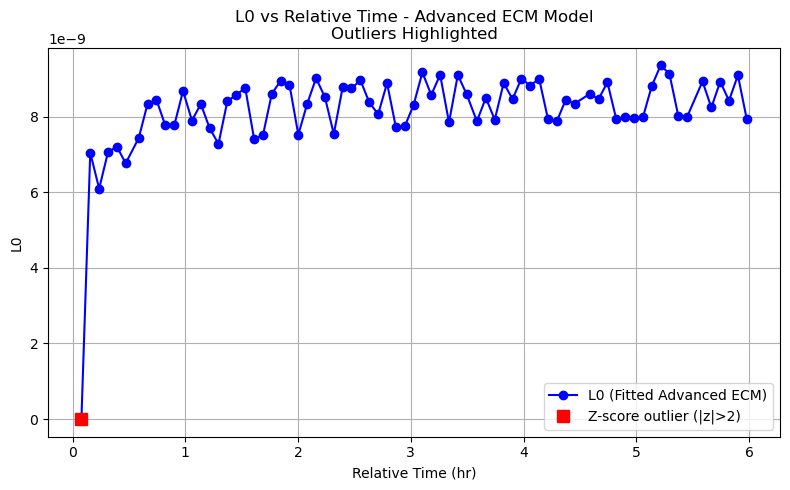

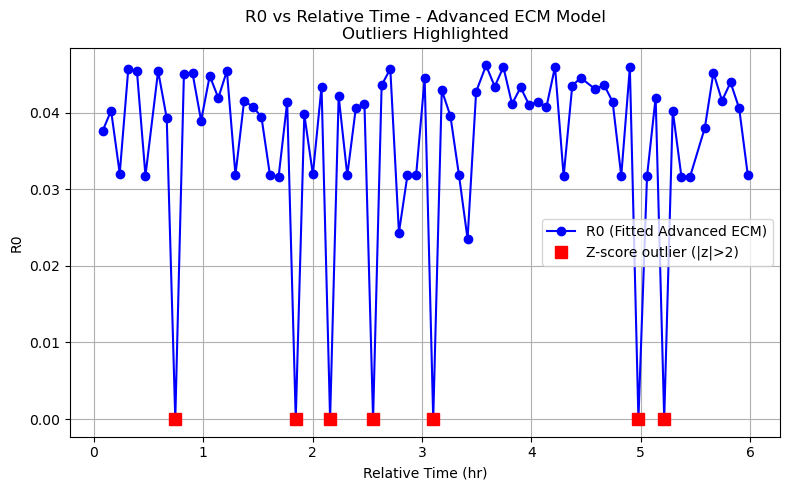

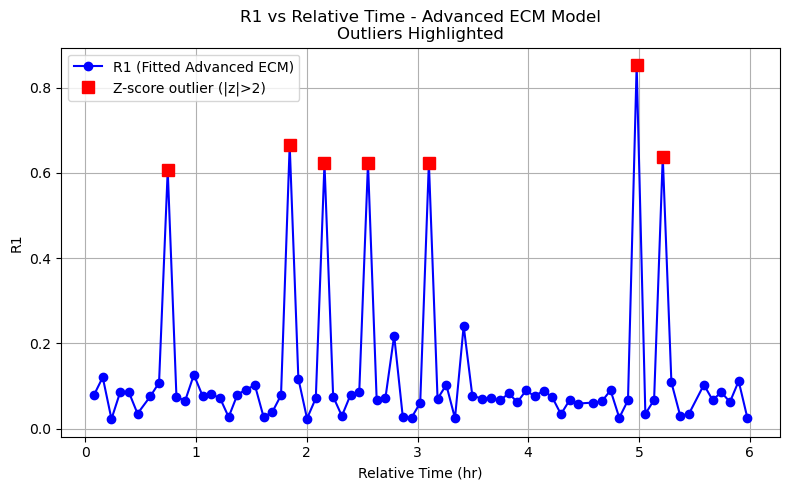

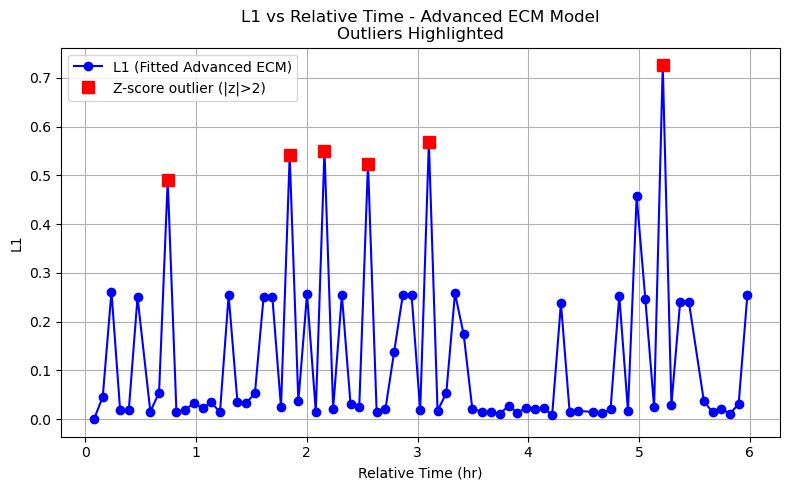

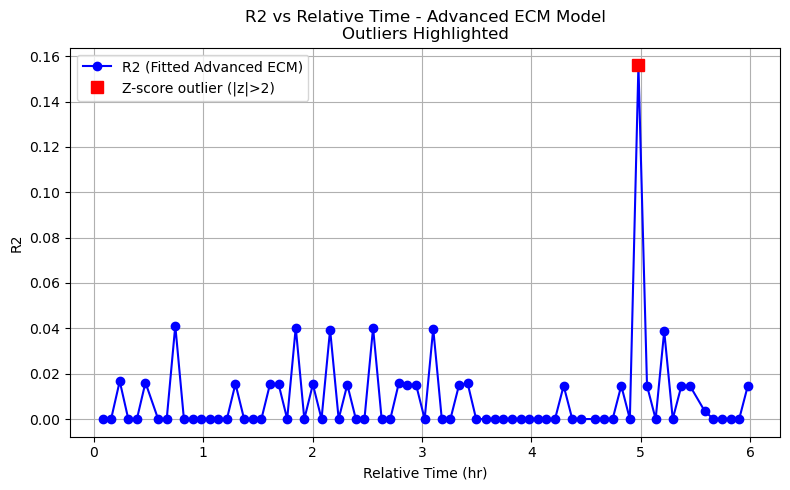

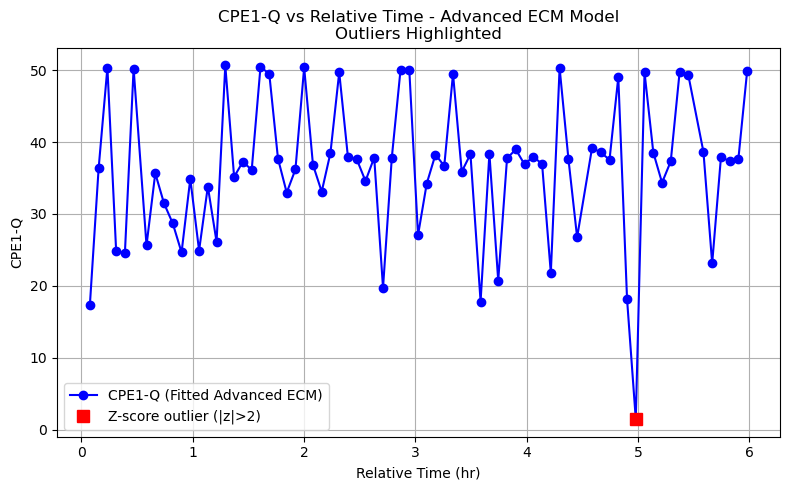

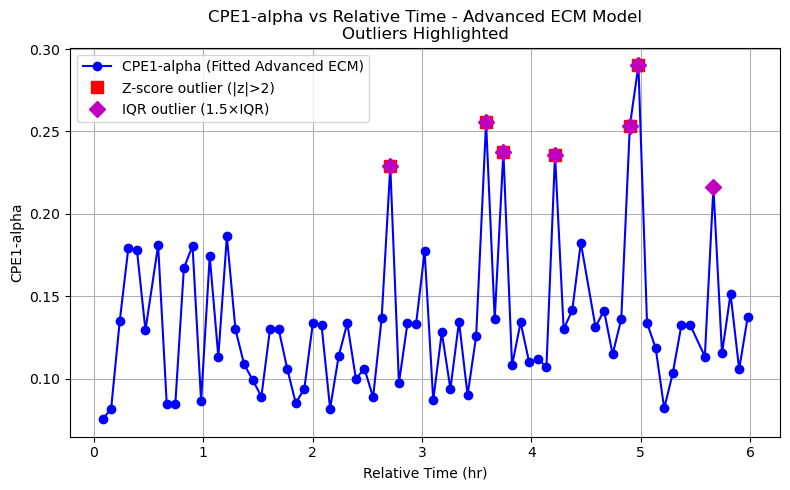

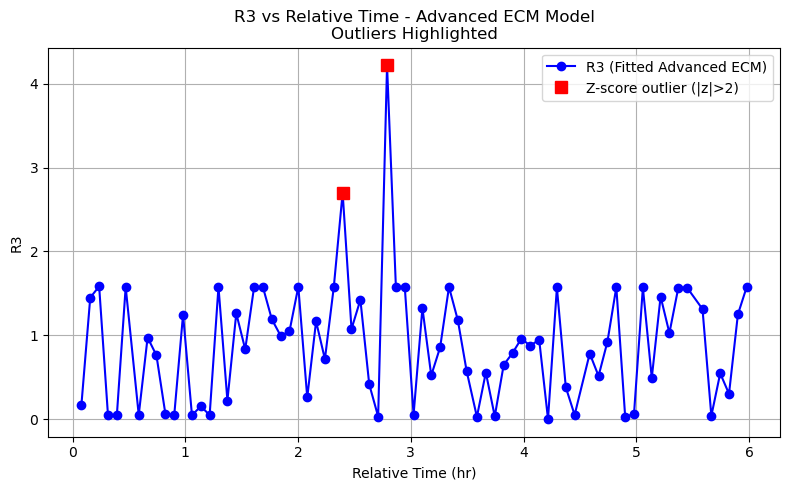

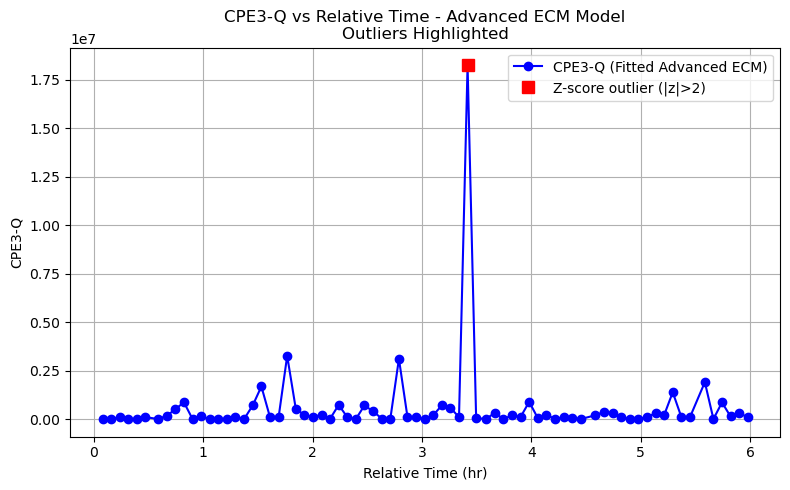

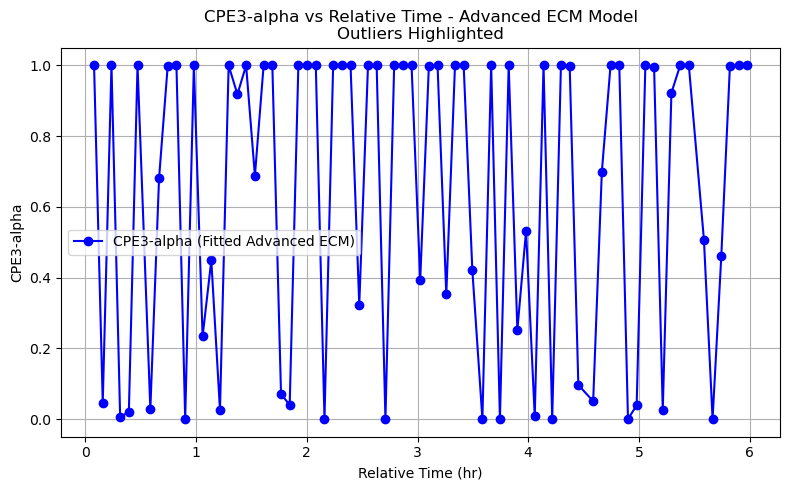

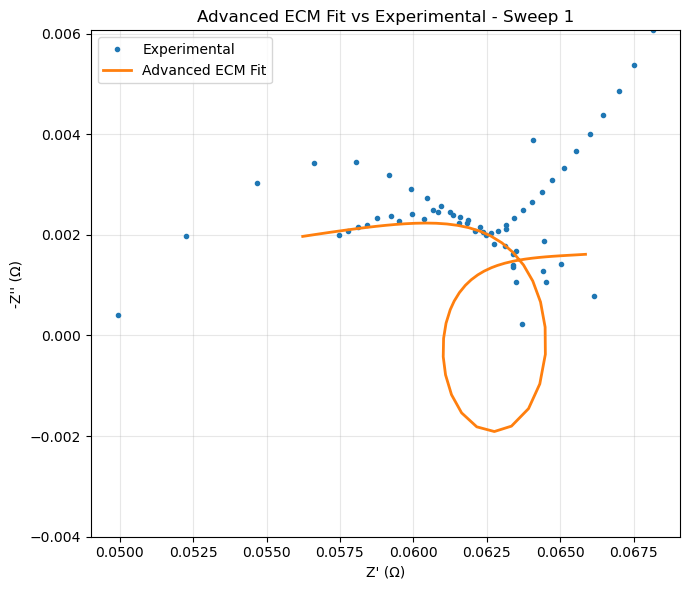

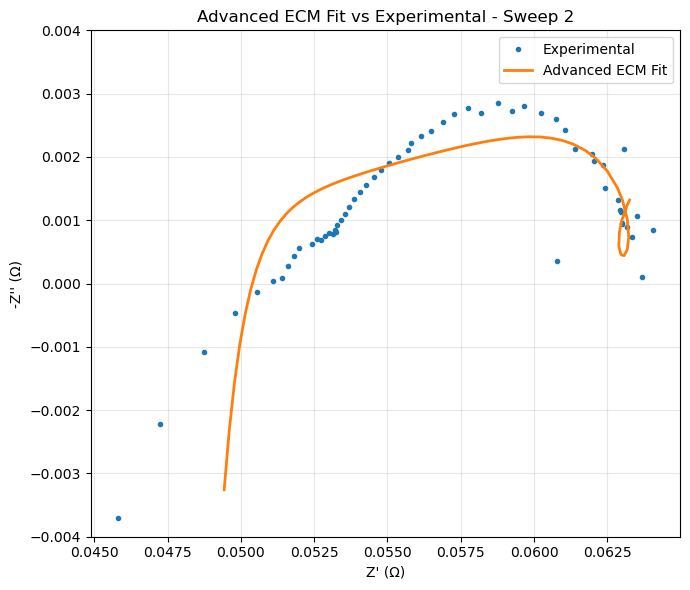

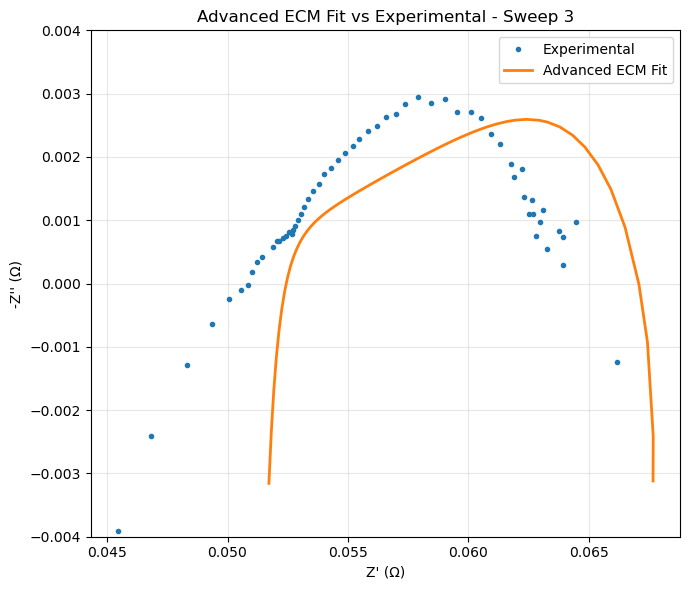

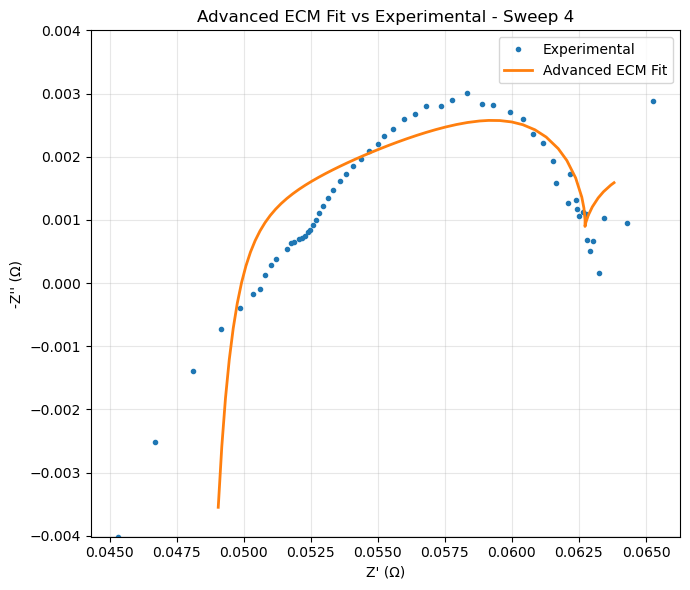

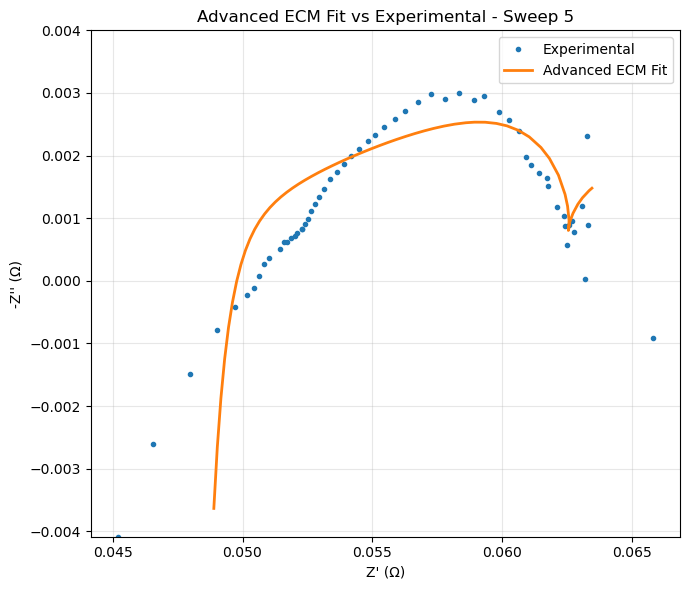

=== RMSE Comparison ===
Majority (n=0): mean RMSE = nan, median RMSE = nan
Outliers (n=74): mean RMSE = 1.205e-03, median RMSE = 9.661e-04
Not enough data in one of the groups to plot examples.


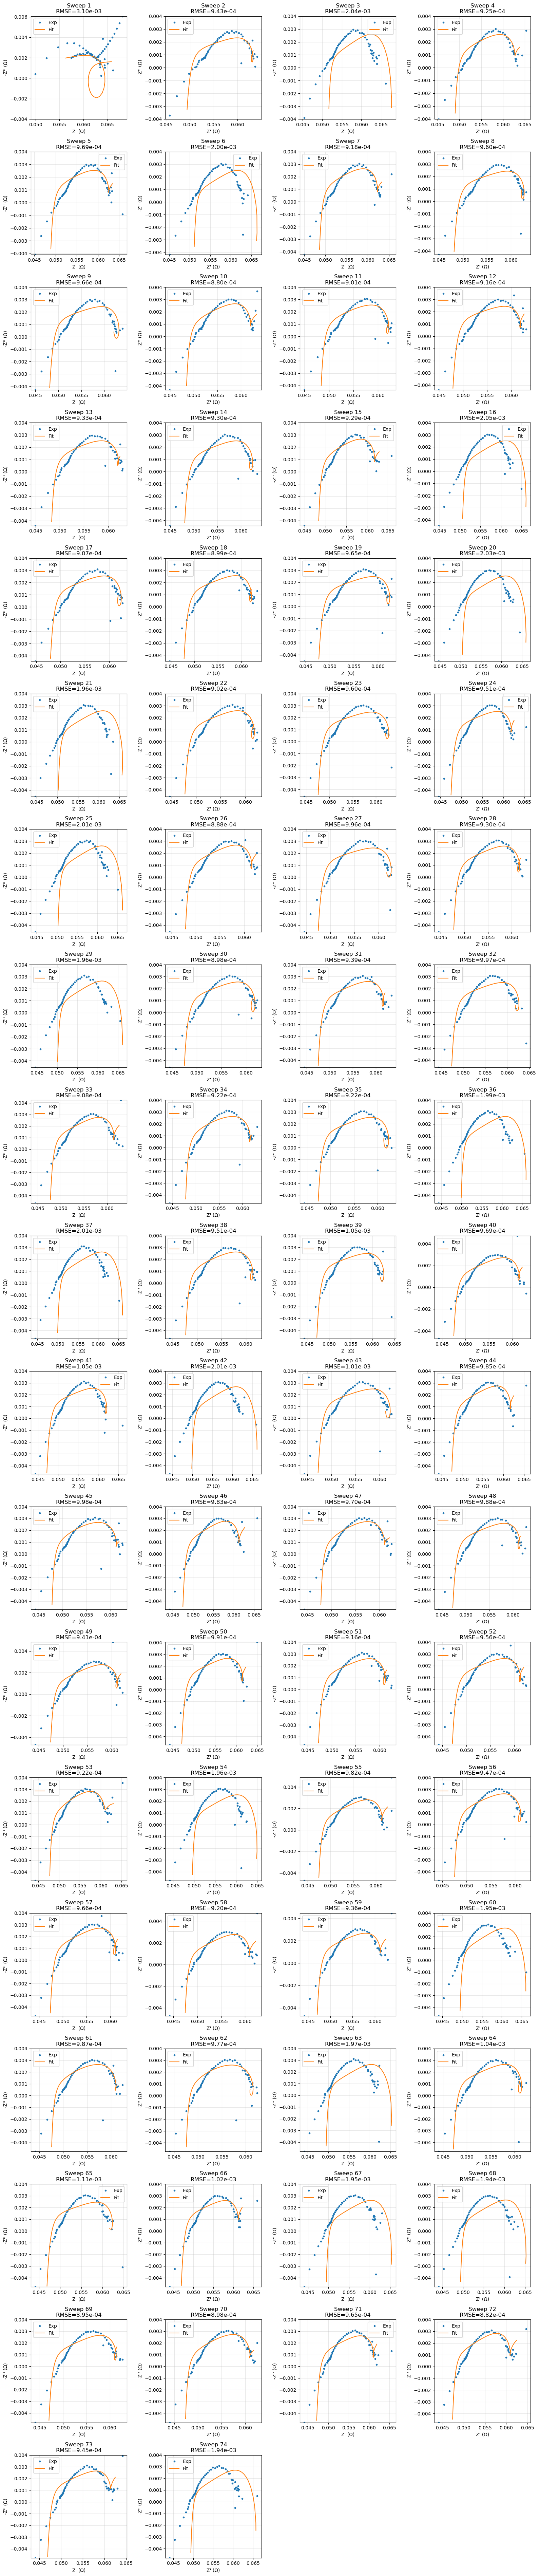

Saved outliers for review to 'outliers_for_review.xlsx':
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000969 -1728.506306   

           bic  sweep_id           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path
from impedance.models.circuits import CustomCircuit
from impedance import preprocessing
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
file_path = "6300.xls"
all_sheets = pd.read_excel(file_path, sheet_name=None)

if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

# 2. DATA CLEANUP & TIME DERIVATION
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

# 4. DEFINE ECM MODELS WITH INITIAL GUESSES
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [0.0, 0.04941, 0.0083883, 2.0785, 0.0083683, 0.46421, 1.0, 2.2071, 1.0, 1.0],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [advanced_model_info]

# 5. ECM FITTING FUNCTION FOR ADVANCED MODEL
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found for any sweep.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

# 6. PLOT ADVANCED MODEL PARAMETERS VS. EXPERIMENTAL VALUES WITH OUTLIER DETECTION
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted Advanced ECM)')
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_outliers = fit_df[abs(z_scores) > 2]
    if not z_outliers.empty:
        plt.plot(z_outliers["RelTime_hr"], z_outliers[pname], 'rs', markersize=8, label='Z-score outlier (|z|>2)')
    if 'alpha' in pname.lower():
        Q1 = fit_df[pname].quantile(0.25)
        Q3 = fit_df[pname].quantile(0.75)
        IQR = Q3 - Q1
        iqr_mask = (fit_df[pname] < (Q1 - 1.5 * IQR)) | (fit_df[pname] > (Q3 + 1.5 * IQR))
        iqr_outliers = fit_df[iqr_mask]
        if not iqr_outliers.empty:
            plt.plot(iqr_outliers["RelTime_hr"], iqr_outliers[pname], 'mD', markersize=8, label='IQR outlier (1.5×IQR)')
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Relative Time - Advanced ECM Model\nOutliers Highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 7. COMPARE ADVANCED MODEL FIT (ECM) VS EXPERIMENTAL (NYQUIST PLOT)
sweep_to_plot_ids = fit_df["sweep_id"].iloc[0:5]
for sweep_id in sweep_to_plot_ids:
    group = df_eis[df_eis["sweep_id"] == sweep_id].sort_values("frequency")
    freq_plot = group["frequency"].values
    Z_exp_plot = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    advanced_row = fit_df[fit_df["sweep_id"] == sweep_id].iloc[0]
    circuit_adv = CustomCircuit(circuit=advanced_model_info["circuit"], initial_guess=advanced_model_info["initial_guess"])
    circuit_adv.parameters_ = advanced_row["params"]
    Z_fit_adv = circuit_adv.predict(freq_plot)
    plt.figure(figsize=(7, 6))
    plt.plot(Z_exp_plot.real, -Z_exp_plot.imag, 'o', label='Experimental', markersize=3)
    plt.plot(Z_fit_adv.real, -Z_fit_adv.imag, '-', label='Advanced ECM Fit', linewidth=2)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f'Advanced ECM Fit vs Experimental - Sweep {sweep_id}')
    plt.legend()
    plt.grid(alpha=0.3)
    imag_range = -Z_exp_plot.imag
    plt.ylim(min(imag_range.min(), -0.004), max(imag_range.max(), 0.004))
    plt.tight_layout()
    plt.show()

# 8. OUTLIERS TAGGING (NYQUIST PLOT), MOVING-WINDOW RMSE COMPARISON & EXAMPLE PLOTTING
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.5
maj = fit_df[~fit_df['is_alpha_outlier']].copy()
out = fit_df[fit_df['is_alpha_outlier']].copy()

maj_mean = maj['rmse'].mean() if not maj.empty else np.nan
maj_med = maj['rmse'].median() if not maj.empty else np.nan
out_mean = out['rmse'].mean() if not out.empty else np.nan
out_med = out['rmse'].median() if not out.empty else np.nan

print("=== RMSE Comparison ===")
print(f"Majority (n={len(maj)}): mean RMSE = {maj_mean:.3e}, median RMSE = {maj_med:.3e}")
print(f"Outliers (n={len(out)}): mean RMSE = {out_mean:.3e}, median RMSE = {out_med:.3e}")

if not maj.empty and not out.empty:
    best_maj_id = maj.loc[maj['rmse'].idxmin(), 'sweep_id']
    worst_out_id = out.loc[out['rmse'].idxmax(), 'sweep_id']
    
    def plot_nyquist_example(sweep_id, label):
        grp = df_eis[df_eis['sweep_id'] == sweep_id].sort_values('frequency')
        freq = grp['frequency'].values
        Z_exp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)
        row = fit_df[fit_df['sweep_id'] == sweep_id].iloc[0]
        circuit = CustomCircuit(circuit=advanced_model_info['circuit'], initial_guess=advanced_model_info["initial_guess"])
        circuit.parameters_ = row['params']
        Z_fit = circuit.predict(freq)
        plt.figure(figsize=(6, 5))
        plt.plot(Z_exp.real, -Z_exp.imag, 'o', label='Experimental', markersize=4)
        plt.plot(Z_fit.real, -Z_fit.imag, '-', label=f'{label} (RMSE={row["rmse"]:.2e})', linewidth=2)
        plt.xlabel("Z' (Ω)")
        plt.ylabel("-Z'' (Ω)")
        plt.title(f"Sweep {sweep_id} — {label}")
        plt.legend()
        plt.grid(alpha=0.3)
        imag_range = -Z_exp.imag
        plt.ylim(min(imag_range.min(), -0.004), max(imag_range.max(), 0.004))
        plt.tight_layout()
        plt.show()

    print(f"\nPlotting best-majority (sweep {best_maj_id}) and worst-outlier (sweep {worst_out_id}):")
    plot_nyquist_example(best_maj_id, "Best Majority")
    plot_nyquist_example(worst_out_id, "Worst Outlier")
else:
    print("Not enough data in one of the groups to plot examples.")

# 9. PLOT ALL OUTLIER SWEEPS
outlier_ids = out['sweep_id'].tolist()
n = len(outlier_ids)
if n > 0:
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), squeeze=False)
    for idx, sweep_id in enumerate(outlier_ids):
        ax = axes[idx // cols][idx % cols]
        grp = df_eis[df_eis['sweep_id'] == sweep_id].sort_values('frequency')
        freq = grp['frequency'].values
        Z_exp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)
        row = fit_df[fit_df['sweep_id'] == sweep_id].iloc[0]
        circ = CustomCircuit(circuit=advanced_model_info['circuit'], initial_guess=advanced_model_info["initial_guess"])
        circ.parameters_ = row['params']
        Z_fit = circ.predict(freq)
        ax.plot(Z_exp.real, -Z_exp.imag, 'o', markersize=3, label='Exp')
        ax.plot(Z_fit.real, -Z_fit.imag, '-', linewidth=1.5, label='Fit')
        ax.set_title(f"Sweep {sweep_id}\nRMSE={row['rmse']:.2e}")
        ax.set_xlabel("Z' (Ω)")
        ax.set_ylabel("-Z'' (Ω)")
        ax.grid(alpha=0.3)
        imag_range = -Z_exp.imag
        ax.set_ylim(min(imag_range.min(), -0.004), max(imag_range.max(), 0.004))
        ax.legend()
    for j in range(n, rows*cols):
        axes[j // cols][j % cols].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No outlier sweeps to plot.")

# 10. SAVE OUTLIERS FOR REVIEW
outlier_results = out.to_dict(orient='records')
if outlier_results:
    review_df = pd.DataFrame(outlier_results)
    review_df.to_excel("outliers_for_review.xlsx", index=False)
    print("Saved outliers for review to 'outliers_for_review.xlsx':")
    print(review_df.head())
else:
    print("No outliers identified for review.")

Total sweeps analyzed: 74
Good fits: 51 (68.9%)
Acceptable fits (including good): 16 (cumulative 90.5%)
Poor fits: 7


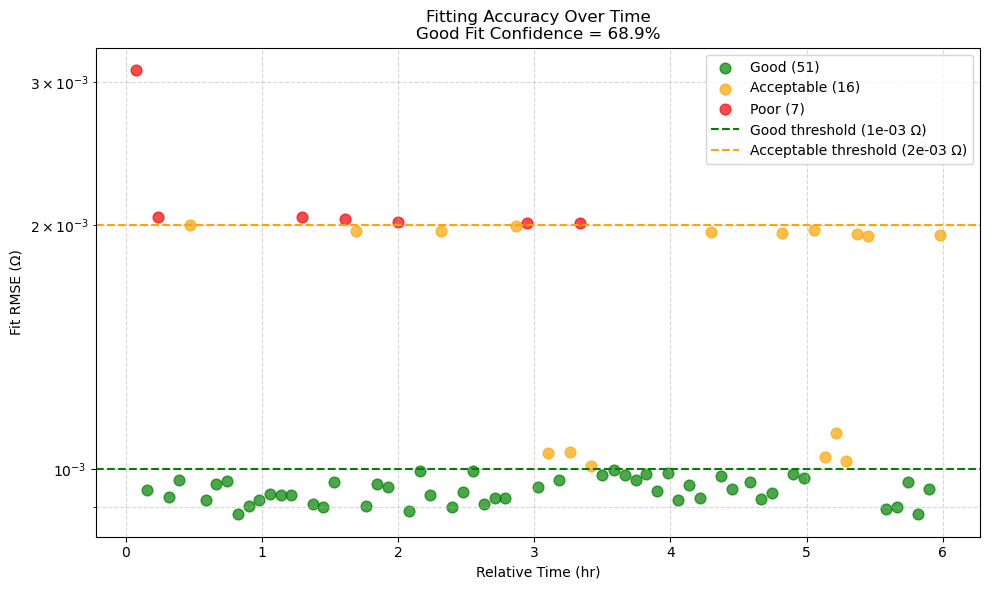

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load your latest fit_df ---
# (Assuming you have it already, if not load 'outliers_for_review.xlsx')
# fit_df = pd.read_excel('outliers_for_review.xlsx')

# --- Set the RMSE thresholds ---
good_threshold = 1e-3   # Good fit threshold
acceptable_threshold = 2e-3  # Acceptable (relaxed) threshold

# --- Classification based on RMSE ---
fit_df['fit_quality'] = np.where(fit_df['rmse'] <= good_threshold, 'Good',
                          np.where(fit_df['rmse'] <= acceptable_threshold, 'Acceptable', 'Poor'))

# --- Calculate percentages ---
total_sweeps = len(fit_df)
good_fits = (fit_df['fit_quality'] == 'Good').sum()
acceptable_fits = (fit_df['fit_quality'] == 'Acceptable').sum()
poor_fits = (fit_df['fit_quality'] == 'Poor').sum()

good_fit_percent = good_fits / total_sweeps * 100
acceptable_fit_percent = (good_fits + acceptable_fits) / total_sweeps * 100

print(f"Total sweeps analyzed: {total_sweeps}")
print(f"Good fits: {good_fits} ({good_fit_percent:.1f}%)")
print(f"Acceptable fits (including good): {acceptable_fits} (cumulative {acceptable_fit_percent:.1f}%)")
print(f"Poor fits: {poor_fits}")

# --- Plot RMSE vs Time ---
plt.figure(figsize=(10, 6))
colors = {'Good':'green', 'Acceptable':'orange', 'Poor':'red'}

for quality, color in colors.items():
    mask = fit_df['fit_quality'] == quality
    plt.scatter(fit_df.loc[mask, 'RelTime_hr'], fit_df.loc[mask, 'rmse'], 
                color=color, label=f"{quality} ({mask.sum()})", s=60, alpha=0.7)

# --- Threshold lines
plt.axhline(good_threshold, color='green', linestyle='--', label=f"Good threshold ({good_threshold:.0e} Ω)")
plt.axhline(acceptable_threshold, color='orange', linestyle='--', label=f"Acceptable threshold ({acceptable_threshold:.0e} Ω)")

plt.yscale('log')
plt.xlabel('Relative Time (hr)')
plt.ylabel('Fit RMSE (Ω)')
plt.title(f"Fitting Accuracy Over Time\nGood Fit Confidence = {good_fit_percent:.1f}%")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()